---
<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>

# **<big><big>Algoritmos y Programación III</big></big>**
**Proyecto final — Clasificación de calidad de frutas**

---

- **Martinez Vasquez Luna Catalina - A00401964**<br>
- **Mosquera Daza Renzo Fernando - A00401681**<br>
- **Tobar Gómez Valentina - A00401749**<br>

---

# Notebook 01 — EDA y comprensión de datos


## 1. Importación de librerías

Cargamos las herramientas que necesitamos para recorrer las carpetas del proyecto, abrir imágenes, construir tablas de revisión y guardar las evidencias del EDA.

In [1]:
from pathlib import Path
import hashlib
import json
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, UnidentifiedImageError
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
RANDOM_STATE = 42

## 2. Rutas del proyecto

Nosotros trabajaremos únicamente con las imágenes propias ubicadas en `data/raw/propias`. En esta primera revisión dejamos preparadas las carpetas de anotaciones, tablas y figuras que van a usar los siguientes notebooks.

In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_ROOT_DIR = PROJECT_ROOT / "data" / "raw"
PROPIAS_DIR = RAW_ROOT_DIR / "propias"
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
TARGET_IMAGE_SIZE = 128

for directory in [PROPIAS_DIR, ANNOTATIONS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proyecto:", PROJECT_ROOT)
print("Datos propios:", PROPIAS_DIR)
print("Anotaciones:", ANNOTATIONS_DIR)
print("Figuras:", FIGURES_DIR)
print("Tablas:", TABLES_DIR)
print("Tamaño para el Notebook 02:", f"{TARGET_IMAGE_SIZE}x{TARGET_IMAGE_SIZE}")

Proyecto: C:\Users\lunam\Desktop\proyecto-final-apo-3
Datos propios: C:\Users\lunam\Desktop\proyecto-final-apo-3\data\raw\propias
Anotaciones: C:\Users\lunam\Desktop\proyecto-final-apo-3\data\annotations
Figuras: C:\Users\lunam\Desktop\proyecto-final-apo-3\results\figures
Tablas: C:\Users\lunam\Desktop\proyecto-final-apo-3\results\tables
Tamaño para el Notebook 02: 128x128


## 3. Definición de etiquetas y normalización

Como las carpetas y archivos pueden venir con nombres distintos, nosotros unificamos las etiquetas de calidad, producto y tamaño. Esto evita errores por mayúsculas, espacios, tildes o nombres mezclados entre español e inglés.

In [3]:
SOURCES = ["own"]
QUALITY_LABELS = ["bad", "regular", "good"]
QUALITY_LABELS_ES = {"bad": "mala", "regular": "regular", "good": "buena"}
SIZE_LABELS = ["small", "medium", "large"]
SIZE_LABELS_ES = {"small": "pequeño", "medium": "mediano", "large": "grande"}
PRODUCT_TYPES = ["apple", "banana", "guava", "lemon", "lime", "orange", "pomegranate", "tomato", "potato", "pepper", "carrot", "onion", "unknown"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

SOURCE_ALIASES = {
    "public": "public",
    "publica": "public",
    "publicas": "public",
    "publico": "public",
    "publicos": "public",
    "dataset": "public",
    "kaggle": "public",
    "train": "public",
    "test": "public",
    "validation": "public",
    "val": "public",
    "own": "own",
    "propia": "own",
    "propias": "own",
    "propio": "own",
    "propios": "own",
    "private": "own",
    "personal": "own"
}

QUALITY_ALIASES = {
    "bad": "bad",
    "bad_quality": "bad",
    "bad_qualt": "bad",
    "bad_quality_fruit": "bad",
    "bad_quality_fruits": "bad",
    "bad_qualt_fruit": "bad",
    "bad_qualt_fruits": "bad",
    "mala": "bad",
    "malas": "bad",
    "malo": "bad",
    "malos": "bad",
    "rotten": "bad",
    "damaged": "bad",
    "poor": "bad",
    "regular": "regular",
    "regular_quality": "regular",
    "regular_qualt": "regular",
    "regular_quality_fruit": "regular",
    "regular_quality_fruits": "regular",
    "regular_qualt_fruit": "regular",
    "regular_qualt_fruits": "regular",
    "medium_quality": "regular",
    "normal": "regular",
    "good": "good",
    "good_quality": "good",
    "good_qualt": "good",
    "good_quality_fruit": "good",
    "good_quality_fruits": "good",
    "good_qualt_fruit": "good",
    "good_qualt_fruits": "good",
    "buena": "good",
    "buenas": "good",
    "bueno": "good",
    "buenos": "good",
    "fresh": "good",
    "healthy": "good"
}

SIZE_ALIASES = {
    "small": "small",
    "pequena": "small",
    "pequeno": "small",
    "pequeña": "small",
    "pequeño": "small",
    "chica": "small",
    "chico": "small",
    "medium": "medium",
    "mediana": "medium",
    "mediano": "medium",
    "regular_size": "medium",
    "large": "large",
    "grande": "large",
    "grandes": "large"
}

PRODUCT_ALIASES = {
    "apple": "apple",
    "apples": "apple",
    "manzana": "apple",
    "manzanas": "apple",
    "banana": "banana",
    "bananas": "banana",
    "platano": "banana",
    "platanos": "banana",
    "guava": "guava",
    "guavas": "guava",
    "guayaba": "guava",
    "guayabas": "guava",
    "lemon": "lemon",
    "lemons": "lemon",
    "limon": "lemon",
    "limones": "lemon",
    "lime": "lime",
    "limes": "lime",
    "orange": "orange",
    "oranges": "orange",
    "naranja": "orange",
    "naranjas": "orange",
    "pomegranate": "pomegranate",
    "pomegranates": "pomegranate",
    "granada": "pomegranate",
    "granadas": "pomegranate",
    "tomato": "tomato",
    "tomatoes": "tomato",
    "tomate": "tomato",
    "tomates": "tomato",
    "potato": "potato",
    "potatoes": "potato",
    "papa": "potato",
    "papas": "potato",
    "pepper": "pepper",
    "pimenton": "pepper",
    "pimentones": "pepper",
    "carrot": "carrot",
    "carrots": "carrot",
    "zanahoria": "carrot",
    "zanahorias": "carrot",
    "onion": "onion",
    "onions": "onion",
    "cebolla": "onion",
    "cebollas": "onion"
}

IGNORED_QUALITY_WORDS = {"quality", "qualt", "qualty", "qualit", "fruits", "fruit", "frutas", "fruta", "mixed", "mix", "regular_size"}


def normalize_text(value):
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


def tokens_from_value(value):
    normalized = normalize_text(value)
    parts = [part for part in normalized.split("_") if part]
    combinations = set(parts + [normalized])

    for start in range(len(parts)):
        for end in range(start + 2, min(len(parts), start + 4) + 1):
            combinations.add("_".join(parts[start:end]))

    return combinations


def resolve_from_aliases(value, aliases):
    for token in tokens_from_value(value):
        if token in aliases:
            return aliases[token]
    return None


def resolve_source(parts, default_source):
    for part in parts:
        source = resolve_from_aliases(part, SOURCE_ALIASES)
        if source in SOURCES:
            return source
    return default_source if default_source in SOURCES else "own"


def resolve_quality(parts):
    for part in parts:
        quality = resolve_from_aliases(part, QUALITY_ALIASES)
        if quality in QUALITY_LABELS:
            return quality
    joined = "_".join(normalize_text(part) for part in parts)
    for label in QUALITY_LABELS:
        if label in joined:
            return label
    return None


def resolve_size(parts):
    for part in parts:
        size = resolve_from_aliases(part, SIZE_ALIASES)
        if size in SIZE_LABELS:
            return size
    return ""


def resolve_product(parts):
    for part in parts:
        product = resolve_from_aliases(part, PRODUCT_ALIASES)
        if product in PRODUCT_TYPES:
            return product
    return "unknown"

## 4. Inventario de imágenes

Revisamos todo lo que exista en `data/raw/propias`. No asumimos una estructura rígida: las etiquetas se infieren desde los nombres de carpetas y archivos para que el registro sea más flexible.

In [4]:
def find_image_files(root):
    if not root.exists():
        return []
    return sorted(path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS and not path.name.startswith("."))


image_sources = [
    {"root": PROPIAS_DIR, "source_default": "own", "root_name": "propias"}
]

inventory_records = []

for item in image_sources:
    files = find_image_files(item["root"])
    inventory_records.append({
        "root_name": item["root_name"],
        "root": item["root"].relative_to(PROJECT_ROOT).as_posix(),
        "source_default": item["source_default"],
        "image_count": len(files)
    })

inventory_df = pd.DataFrame(inventory_records)
inventory_path = TABLES_DIR / "01_folder_inventory.csv"
inventory_df.to_csv(inventory_path, index=False, encoding="utf-8")

display(inventory_df)
print("Inventario guardado en:", inventory_path)

,root_name,root,source_default,image_count
0,propias,data/raw/propias,own,8610


Inventario guardado en: C:\Users\lunam\Desktop\proyecto-final-apo-3\results\tables\01_folder_inventory.csv


## 5. Construcción de `labels.csv`

Cada imagen válida queda representada con fuente, calidad, producto, tamaño manual si aparece en la ruta, dimensiones, hash y algunas señales visuales iniciales. Las imágenes sin calidad reconocible no se usan para modelado y quedan reportadas para revisión.

In [5]:
ANALYSIS_MAX_SIDE = 256


def image_metadata(image_path):
    file_size = image_path.stat().st_size

    with Image.open(image_path) as image:
        orientation = image.getexif().get(274, 1)
        original_width, original_height = image.size

        if orientation in {5, 6, 7, 8}:
            width, height = original_height, original_width
        else:
            width, height = original_width, original_height

        image.draft("RGB", (ANALYSIS_MAX_SIDE, ANALYSIS_MAX_SIDE))
        image = ImageOps.exif_transpose(image).convert("RGB")
        image.thumbnail(
            (ANALYSIS_MAX_SIDE, ANALYSIS_MAX_SIDE),
            Image.Resampling.BILINEAR
        )

        mode = image.mode
        image_array = np.asarray(image, dtype=np.uint8)

    image_float = image_array.astype(np.float32)
    gray = image_float.mean(axis=2)

    gradient_x = np.diff(gray, axis=1)
    gradient_y = np.diff(gray, axis=0)

    if gradient_x.size and gradient_y.size:
        blur_score = float(np.var(gradient_x) + np.var(gradient_y))
    else:
        blur_score = 0.0

    brightness_mean = float(gray.mean())
    brightness_std = float(gray.std())

    red = image_array[:, :, 0].astype(np.int16)
    green = image_array[:, :, 1].astype(np.int16)
    blue = image_array[:, :, 2].astype(np.int16)

    max_channel = image_array.max(axis=2).astype(np.int16)
    min_channel = image_array.min(axis=2).astype(np.int16)

    skin_mask = (
        (red > 95)
        & (green > 40)
        & (blue > 20)
        & ((max_channel - min_channel) > 15)
        & (red > green)
        & (red > blue)
    )

    skin_ratio = float(skin_mask.mean())

    border_pixels = np.concatenate(
        [
            image_array[0, :, :],
            image_array[-1, :, :],
            image_array[:, 0, :],
            image_array[:, -1, :]
        ],
        axis=0
    )

    border_std = float(border_pixels.std())
    border_mean = border_pixels.astype(np.float32).mean(axis=0)

    color_difference = image_float - border_mean
    color_distance_squared = np.sum(color_difference ** 2, axis=2)
    foreground_ratio = float((color_distance_squared > 35 ** 2).mean())

    hash_builder = hashlib.md5()
    hash_builder.update(image_array.tobytes())
    hash_builder.update(f"{width}x{height}".encode("utf-8"))
    hash_builder.update(str(file_size).encode("utf-8"))
    image_hash = hash_builder.hexdigest()

    return (
        width,
        height,
        mode,
        image_hash,
        blur_score,
        brightness_mean,
        brightness_std,
        skin_ratio,
        border_std,
        foreground_ratio
    )


def build_record(image_path, root, source_default):
    relative_parts = image_path.relative_to(root).parts
    inference_parts = list(relative_parts[:-1]) + [image_path.stem]

    source = resolve_source(inference_parts, source_default)
    quality_label = resolve_quality(inference_parts)
    size_label_manual = resolve_size(inference_parts)
    product_type = resolve_product(inference_parts)

    if quality_label is None:
        return None, "missing_quality"

    (
        width,
        height,
        mode,
        image_hash,
        blur_score,
        brightness_mean,
        brightness_std,
        skin_ratio,
        border_std,
        foreground_ratio
    ) = image_metadata(image_path)

    return {
        "image_id": f"img_{image_hash[:12]}",
        "source": source,
        "quality_label": quality_label,
        "quality_label_es": QUALITY_LABELS_ES[quality_label],
        "fruit_type": product_type,
        "product_type": product_type,
        "size_label_manual": size_label_manual,
        "relative_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
        "file_name": image_path.name,
        "width": int(width),
        "height": int(height),
        "aspect_ratio": round(width / height, 6) if height else np.nan,
        "is_square": bool(width == height),
        "requires_crop": bool(width != height),
        "mode": mode,
        "file_size_kb": round(image_path.stat().st_size / 1024, 3),
        "blur_score": round(blur_score, 6),
        "brightness_mean": round(brightness_mean, 6),
        "brightness_std": round(brightness_std, 6),
        "skin_tone_ratio": round(skin_ratio, 6),
        "border_std": round(border_std, 6),
        "foreground_ratio_border": round(foreground_ratio, 6),
        "image_hash": image_hash
    }, "ok"


image_jobs = []

for item in image_sources:
    for image_path in find_image_files(item["root"]):
        image_jobs.append(
            (
                image_path,
                item["root"],
                item["source_default"]
            )
        )

records = []
review_records = []
total_images = len(image_jobs)

print("Imágenes encontradas:", total_images)

for index, (image_path, root, source_default) in enumerate(image_jobs, start=1):
    try:
        record, status = build_record(
            image_path,
            root,
            source_default
        )
    except (UnidentifiedImageError, OSError, ValueError) as error:
        review_records.append({
            "relative_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
            "status": "invalid_image",
            "detail": str(error)
        })
        record = None
        status = "invalid_image"

    if record is None and status != "invalid_image":
        review_records.append({
            "relative_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
            "status": status,
            "detail": "No pudimos inferir calidad desde la ruta o el nombre del archivo"
        })

    if record is not None:
        records.append(record)

    if index % 250 == 0 or index == total_images:
        print(
            f"Procesadas {index}/{total_images} imágenes "
            f"({index / total_images:.1%})"
        )

columns = [
    "image_id",
    "source",
    "quality_label",
    "quality_label_es",
    "fruit_type",
    "product_type",
    "size_label_manual",
    "relative_path",
    "file_name",
    "width",
    "height",
    "aspect_ratio",
    "is_square",
    "requires_crop",
    "mode",
    "file_size_kb",
    "blur_score",
    "brightness_mean",
    "brightness_std",
    "skin_tone_ratio",
    "border_std",
    "foreground_ratio_border",
    "image_hash"
]

df = pd.DataFrame(records, columns=columns)

review_invalid_df = pd.DataFrame(
    review_records,
    columns=["relative_path", "status", "detail"]
)

if df.empty:
    raise ValueError(
        "No encontramos imágenes válidas con etiqueta de calidad. "
        "Revisa data/raw/propias."
    )

df = df.sort_values(
    ["source", "quality_label", "fruit_type", "file_name"]
).reset_index(drop=True)

labels_path = ANNOTATIONS_DIR / "labels.csv"
df.to_csv(labels_path, index=False, encoding="utf-8")

review_invalid_path = ANNOTATIONS_DIR / "image_invalid_paths.csv"
review_invalid_df.to_csv(
    review_invalid_path,
    index=False,
    encoding="utf-8"
)

print("Imágenes válidas registradas:", len(df))
print("Imágenes pendientes de revisión:", len(review_invalid_df))
print("Archivo principal:", labels_path)
print("Archivo de revisión:", review_invalid_path)

display(df.head())
display(review_invalid_df.head(20))

Imágenes encontradas: 8610
Procesadas 250/8610 imágenes (2.9%)
Procesadas 500/8610 imágenes (5.8%)
Procesadas 750/8610 imágenes (8.7%)
Procesadas 1000/8610 imágenes (11.6%)
Procesadas 1250/8610 imágenes (14.5%)
Procesadas 1500/8610 imágenes (17.4%)
Procesadas 1750/8610 imágenes (20.3%)
Procesadas 2000/8610 imágenes (23.2%)
Procesadas 2250/8610 imágenes (26.1%)
Procesadas 2500/8610 imágenes (29.0%)
Procesadas 2750/8610 imágenes (31.9%)
Procesadas 3000/8610 imágenes (34.8%)
Procesadas 3250/8610 imágenes (37.7%)
Procesadas 3500/8610 imágenes (40.7%)
Procesadas 3750/8610 imágenes (43.6%)
Procesadas 4000/8610 imágenes (46.5%)
Procesadas 4250/8610 imágenes (49.4%)
Procesadas 4500/8610 imágenes (52.3%)
Procesadas 4750/8610 imágenes (55.2%)
Procesadas 5000/8610 imágenes (58.1%)
Procesadas 5250/8610 imágenes (61.0%)
Procesadas 5500/8610 imágenes (63.9%)
Procesadas 5750/8610 imágenes (66.8%)
Procesadas 6000/8610 imágenes (69.7%)
Procesadas 6250/8610 imágenes (72.6%)
Procesadas 6500/8610 imágenes

,image_id,source,quality_label,quality_label_es,fruit_type,product_type,size_label_manual,relative_path,file_name,width,height,aspect_ratio,is_square,requires_crop,mode,file_size_kb,blur_score,brightness_mean,brightness_std,skin_tone_ratio,border_std,foreground_ratio_border,image_hash
0,img_741d1d5b01b1,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg,IMG-20260603-WA0146.jpg,3024,4032,0.75,False,True,RGB,696.525,81.042206,149.671753,55.716446,0.509745,41.783994,0.876892,741d1d5b01b1001d33067d909033f455
1,img_6175eda1324a,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg,IMG-20260603-WA0148.jpg,3024,4032,0.75,False,True,RGB,904.622,64.755966,140.762543,54.282360,0.654683,55.371459,0.879476,6175eda1324a6261d19113e44e267094
2,img_15b25200b987,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg,IMG-20260603-WA0150.jpg,3024,4032,0.75,False,True,RGB,845.356,78.422165,140.391068,54.991219,0.708842,43.160381,0.882243,15b25200b9879c62c181d26fe6572b1a
3,img_17d44cef3f35,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg,IMG-20260603-WA0152.jpg,3024,4032,0.75,False,True,RGB,834.975,79.099014,141.243866,54.749615,0.696025,50.036350,0.776082,17d44cef3f35ad1b13fa9a8ad066f1c1
4,img_5a36d1b3a091,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg,IMG-20260603-WA0154.jpg,3024,4032,0.75,False,True,RGB,801.359,63.061516,129.594528,44.777149,0.658671,43.308986,0.783488,5a36d1b3a091b19ab6456eb6f5ad40b1


,relative_path,status,detail


## 6. Diccionario de datos

Dejamos documentado qué significa cada columna generada para que el Notebook 02 y los modelos usen el mismo contrato de datos.

In [6]:
data_dictionary = pd.DataFrame([
    ["image_id", "Identificador reproducible construido desde el hash de la imagen"],
    ["source", "Origen de la imagen. En esta versión usamos únicamente own"],
    ["quality_label", "Etiqueta objetivo de calidad: bad, regular o good"],
    ["quality_label_es", "Etiqueta de calidad en español"],
    ["fruit_type", "Tipo de fruta o verdura inferido desde la ruta"],
    ["product_type", "Copia de fruit_type para usar una palabra más general en el proyecto"],
    ["size_label_manual", "Etiqueta manual de tamaño si aparece en carpetas o nombres"],
    ["relative_path", "Ruta relativa a la raíz del proyecto"],
    ["width", "Ancho original en píxeles"],
    ["height", "Alto original en píxeles"],
    ["aspect_ratio", "Relación ancho/alto"],
    ["is_square", "Indica si la imagen original es cuadrada"],
    ["requires_crop", "Indica si el preprocesamiento debe ajustar la proporción"],
    ["mode", "Modo de color leído con PIL"],
    ["file_size_kb", "Peso del archivo en kilobytes"],
    ["blur_score", "Medida inicial de nitidez basada en variación de gradientes"],
    ["brightness_mean", "Brillo promedio de la imagen en escala de grises"],
    ["brightness_std", "Variación del brillo en la imagen"],
    ["skin_tone_ratio", "Proporción aproximada de píxeles con tonos similares a piel"],
    ["border_std", "Variación de color en los bordes de la imagen"],
    ["foreground_ratio_border", "Proporción aproximada de píxeles que se diferencian del borde"],
    ["image_hash", "Hash MD5 para detectar duplicados exactos"]
], columns=["columna", "descripcion"])

data_dictionary_path = ANNOTATIONS_DIR / "data_dictionary.md"
markdown_lines = [
    "| columna | descripcion |",
    "|---|---|"
]

for _, row in data_dictionary.iterrows():
    column_name = str(row["columna"]).replace("|", "\\|")
    description = str(row["descripcion"]).replace("|", "\\|")
    markdown_lines.append(f"| {column_name} | {description} |")

with open(data_dictionary_path, "w", encoding="utf-8") as file:
    file.write("\n".join(markdown_lines))

display(data_dictionary)
print("Diccionario guardado en:", data_dictionary_path)

,columna,descripcion
0,image_id,Identificador reproducible construido desde el hash de la imagen
1,source,Origen de la imagen. En esta versión usamos únicamente own
2,quality_label,"Etiqueta objetivo de calidad: bad, regular o good"
3,quality_label_es,Etiqueta de calidad en español
4,fruit_type,Tipo de fruta o verdura inferido desde la ruta
5,product_type,Copia de fruit_type para usar una palabra más general en el proyecto
6,size_label_manual,Etiqueta manual de tamaño si aparece en carpetas o nombres
7,relative_path,Ruta relativa a la raíz del proyecto
8,width,Ancho original en píxeles
9,height,Alto original en píxeles


Diccionario guardado en: C:\Users\lunam\Desktop\proyecto-final-apo-3\data\annotations\data_dictionary.md


## 7. Balance por calidad

La variable objetivo principal es `quality_label`. Este balance nos dice si después necesitaremos balancear el dataset, usar pesos por clase o reforzar alguna categoría con más imágenes propias.

,quality_label,count,percentage,quality_label_es
0,bad,1489,17.29,mala
1,regular,4493,52.18,regular
2,good,2628,30.52,buena


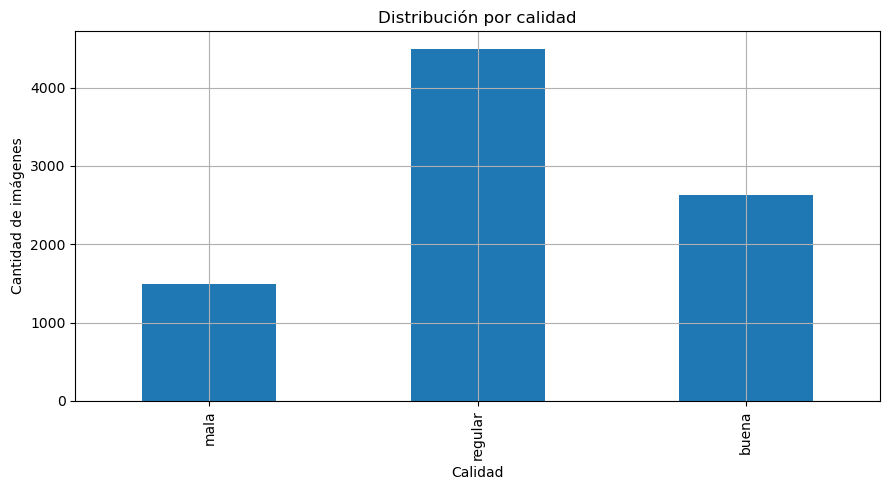

In [7]:
quality_counts = df.groupby("quality_label").size().reindex(QUALITY_LABELS, fill_value=0).reset_index(name="count")
quality_counts["percentage"] = (quality_counts["count"] / len(df) * 100).round(2)
quality_counts["quality_label_es"] = quality_counts["quality_label"].map(QUALITY_LABELS_ES)
quality_counts_path = TABLES_DIR / "02_quality_distribution.csv"
quality_counts.to_csv(quality_counts_path, index=False, encoding="utf-8")

display(quality_counts)
ax = quality_counts.set_index("quality_label_es")["count"].plot(kind="bar")
ax.set_title("Distribución por calidad")
ax.set_xlabel("Calidad")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_quality_distribution.png", dpi=160)
plt.show()

## 8. Distribución por fuente

Confirmamos que el notebook está trabajando con las imágenes propias. Esta tabla queda como control para evitar que entren imágenes públicas en el flujo actual.

quality_label,bad,regular,good
source,,,
own,1489,4493,2628


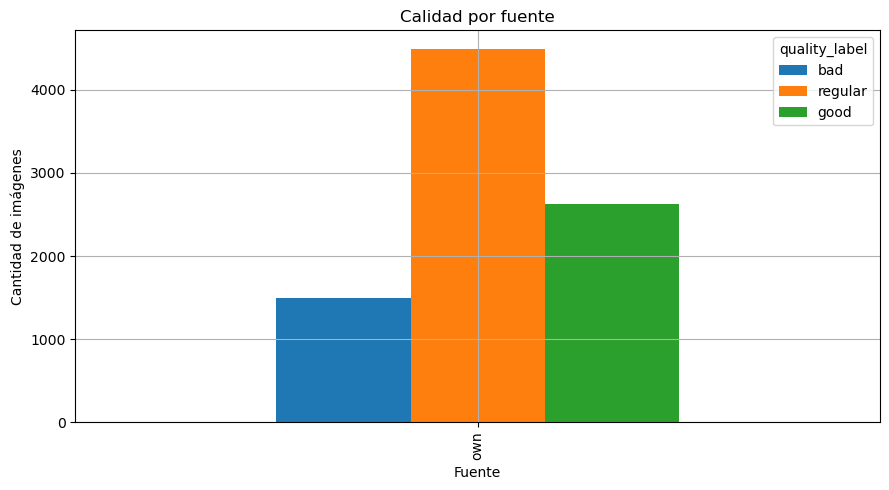

In [8]:
source_quality_table = pd.crosstab(df["source"], df["quality_label"]).reindex(index=SOURCES, columns=QUALITY_LABELS, fill_value=0)
source_quality_path = TABLES_DIR / "03_quality_by_source.csv"
source_quality_table.to_csv(source_quality_path, encoding="utf-8")

display(source_quality_table)
ax = source_quality_table.plot(kind="bar")
ax.set_title("Calidad por fuente")
ax.set_xlabel("Fuente")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_quality_by_source.png", dpi=160)
plt.show()

## 9. Cobertura por fruta o verdura

Este cruce permite ver qué productos tienen ejemplos suficientes y cuáles deberían reforzarse antes de entrenar modelos.

,product_type,count
5,pomegranate,3088
0,apple,1310
2,guava,1148
1,banana,1141
3,lime,1096
4,orange,827


quality_label,bad,regular,good
product_type,,,
apple,153,890,267
banana,4,936,201
guava,135,813,200
lime,152,744,200
orange,111,510,206
pomegranate,934,600,1554


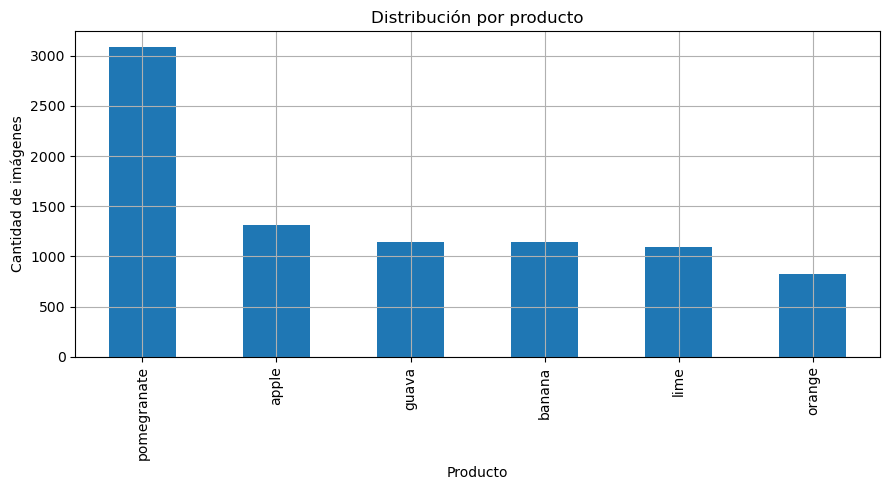

In [9]:
product_counts = df.groupby("product_type").size().reset_index(name="count").sort_values("count", ascending=False)
product_quality_table = pd.crosstab(df["product_type"], df["quality_label"]).reindex(columns=QUALITY_LABELS, fill_value=0)
product_counts_path = TABLES_DIR / "04_product_distribution.csv"
product_quality_path = TABLES_DIR / "05_quality_by_product.csv"
product_counts.to_csv(product_counts_path, index=False, encoding="utf-8")
product_quality_table.to_csv(product_quality_path, encoding="utf-8")

display(product_counts)
display(product_quality_table)
ax = product_counts.set_index("product_type")["count"].plot(kind="bar")
ax.set_title("Distribución por producto")
ax.set_xlabel("Producto")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_product_distribution.png", dpi=160)
plt.show()

## 10. Revisión de tamaño manual

Si las carpetas o archivos ya incluyen tamaño, lo registramos. Si no aparece, el Notebook 02 tendrá que estimarlo desde la imagen con mucho cuidado, porque la distancia de la cámara puede hacer que una fruta pequeña parezca grande o que una fruta grande parezca pequeña.

In [10]:
manual_size_counts = df["size_label_manual"].replace("", np.nan).value_counts(dropna=False).rename_axis("size_label_manual").reset_index(name="count")
manual_size_counts["percentage"] = (manual_size_counts["count"] / len(df) * 100).round(2)
manual_size_path = TABLES_DIR / "06_manual_size_distribution.csv"
manual_size_counts.to_csv(manual_size_path, index=False, encoding="utf-8")

display(manual_size_counts)
print("Imágenes sin tamaño manual:", int((df["size_label_manual"] == "").sum()))

,size_label_manual,count,percentage
0,NaN,8610,100.0


Imágenes sin tamaño manual: 8610


## 11. Dimensiones y condiciones visuales

El EDA no transforma las imágenes finales. Aquí solo identificamos condiciones que pueden afectar la limpieza: imágenes no cuadradas, resoluciones bajas, poca nitidez, iluminación extrema, fondos muy mezclados o posible presencia de manos u otros objetos.

,count,mean,std,min,25%,50%,75%,max
width,8610.0,1372.933217,1309.375091,13.000000,130.000000,720.000000,3120.000000,4032.000000
height,8610.0,1268.588966,1312.832708,12.000000,122.000000,720.000000,3120.000000,4032.000000
aspect_ratio,8610.0,1.163955,0.406790,0.268817,1.000000,1.000000,1.255814,3.833333
file_size_kb,8610.0,381.779175,455.833748,0.688000,7.126250,133.484000,777.008750,2591.952000
blur_score,8610.0,246.947899,319.741667,0.736139,74.251211,140.334786,296.994751,3498.918945
brightness_mean,8610.0,116.931295,30.305947,12.170437,99.254805,111.080925,131.806770,244.411392
brightness_std,8610.0,48.549961,13.427092,4.091359,40.733746,46.629935,54.568014,106.093185
skin_tone_ratio,8610.0,0.429420,0.222233,0.000000,0.260244,0.425083,0.578739,1.000000
border_std,8610.0,45.109256,22.837250,0.000000,36.294650,46.572893,56.800772,126.139684
foreground_ratio_border,8610.0,0.766624,0.198285,0.000000,0.640020,0.838650,0.917134,1.000000


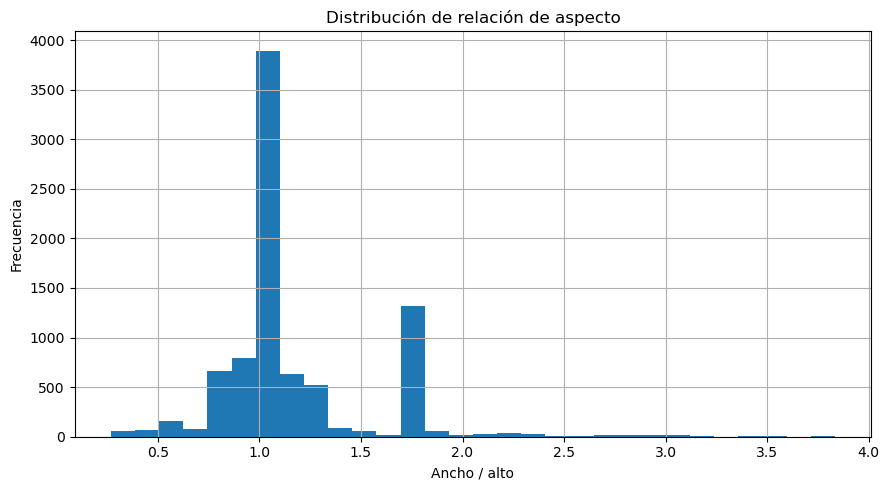

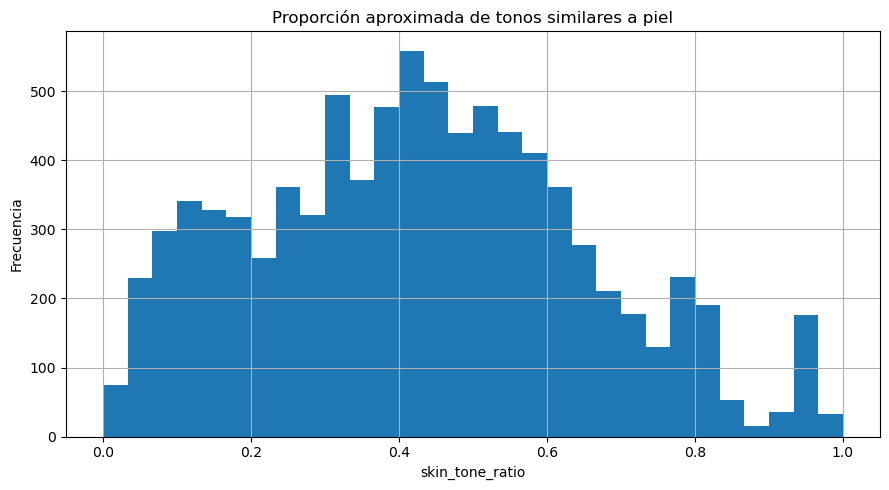

In [11]:
dimension_columns = ["width", "height", "aspect_ratio", "file_size_kb", "blur_score", "brightness_mean", "brightness_std", "skin_tone_ratio", "border_std", "foreground_ratio_border"]
dimension_summary = df[dimension_columns].describe().T
dimension_summary_path = TABLES_DIR / "07_dimension_summary.csv"
dimension_summary.to_csv(dimension_summary_path, encoding="utf-8")

display(dimension_summary)
ax = df["aspect_ratio"].plot(kind="hist", bins=30)
ax.set_title("Distribución de relación de aspecto")
ax.set_xlabel("Ancho / alto")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_aspect_ratio_distribution.png", dpi=160)
plt.show()

ax = df["skin_tone_ratio"].plot(kind="hist", bins=30)
ax.set_title("Proporción aproximada de tonos similares a piel")
ax.set_xlabel("skin_tone_ratio")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_skin_tone_ratio_distribution.png", dpi=160)
plt.show()

## 12. Tabla de revisión antes del preprocesamiento

Generamos una lista de imágenes que conviene revisar. No eliminamos datos en este notebook; solo dejamos evidencia para que la limpieza del Notebook 02 tome mejores decisiones.

In [12]:
review_df = df.copy()
review_df["review_reason"] = ""
blur_threshold = df["blur_score"].quantile(0.10)
skin_threshold = max(0.18, df["skin_tone_ratio"].quantile(0.90))
foreground_low_threshold = df["foreground_ratio_border"].quantile(0.10)
foreground_high_threshold = df["foreground_ratio_border"].quantile(0.90)
review_df.loc[review_df["requires_crop"], "review_reason"] = review_df.loc[review_df["requires_crop"], "review_reason"] + "requires_square_adjustment;"
review_df.loc[~review_df["mode"].isin(["RGB", "RGBA"]), "review_reason"] = review_df.loc[~review_df["mode"].isin(["RGB", "RGBA"]), "review_reason"] + "non_rgb_mode;"
review_df.loc[(review_df["width"] < TARGET_IMAGE_SIZE) | (review_df["height"] < TARGET_IMAGE_SIZE), "review_reason"] = review_df.loc[(review_df["width"] < TARGET_IMAGE_SIZE) | (review_df["height"] < TARGET_IMAGE_SIZE), "review_reason"] + "low_resolution;"
review_df.loc[review_df["size_label_manual"] == "", "review_reason"] = review_df.loc[review_df["size_label_manual"] == "", "review_reason"] + "size_will_be_estimated;"
review_df.loc[review_df["blur_score"] <= blur_threshold, "review_reason"] = review_df.loc[review_df["blur_score"] <= blur_threshold, "review_reason"] + "possible_blur;"
review_df.loc[review_df["skin_tone_ratio"] >= skin_threshold, "review_reason"] = review_df.loc[review_df["skin_tone_ratio"] >= skin_threshold, "review_reason"] + "possible_hand_or_skin_tone_object;"
review_df.loc[review_df["foreground_ratio_border"] <= foreground_low_threshold, "review_reason"] = review_df.loc[review_df["foreground_ratio_border"] <= foreground_low_threshold, "review_reason"] + "possible_low_contrast_background;"
review_df.loc[review_df["foreground_ratio_border"] >= foreground_high_threshold, "review_reason"] = review_df.loc[review_df["foreground_ratio_border"] >= foreground_high_threshold, "review_reason"] + "possible_background_noise;"
image_review = review_df[review_df["review_reason"] != ""].copy()
image_review_path = ANNOTATIONS_DIR / "image_review.csv"
image_review.to_csv(image_review_path, index=False, encoding="utf-8")

print("Imágenes marcadas para revisión:", len(image_review))
print("Archivo generado:", image_review_path)
display(image_review[["image_id", "source", "quality_label", "product_type", "size_label_manual", "relative_path", "width", "height", "mode", "blur_score", "skin_tone_ratio", "foreground_ratio_border", "review_reason"]].head(30))

Imágenes marcadas para revisión: 8610
Archivo generado: C:\Users\lunam\Desktop\proyecto-final-apo-3\data\annotations\image_review.csv


,image_id,source,quality_label,product_type,size_label_manual,relative_path,width,height,mode,blur_score,skin_tone_ratio,foreground_ratio_border,review_reason
0,img_741d1d5b01b1,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg,3024,4032,RGB,81.042206,0.509745,0.876892,requires_square_adjustment;size_will_be_estimated;
1,img_6175eda1324a,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg,3024,4032,RGB,64.755966,0.654683,0.879476,requires_square_adjustment;size_will_be_estimated;
2,img_15b25200b987,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg,3024,4032,RGB,78.422165,0.708842,0.882243,requires_square_adjustment;size_will_be_estimated;
3,img_17d44cef3f35,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg,3024,4032,RGB,79.099014,0.696025,0.776082,requires_square_adjustment;size_will_be_estimated;
4,img_5a36d1b3a091,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg,3024,4032,RGB,63.061516,0.658671,0.783488,requires_square_adjustment;size_will_be_estimated;
5,img_d3c6186ec8eb,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0156.jpg,3024,4032,RGB,45.564140,0.632751,0.855103,requires_square_adjustment;size_will_be_estimated;
6,img_74eae4b0c491,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0158.jpg,3024,4032,RGB,79.955551,0.869954,0.725118,requires_square_adjustment;size_will_be_estimated;possible_hand_or_skin_tone_object;
7,img_d007c1a7c720,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0160.jpg,3024,4032,RGB,94.218536,0.861674,0.671509,requires_square_adjustment;size_will_be_estimated;possible_hand_or_skin_tone_object;
8,img_9e7e6eb4cadb,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0162.jpg,3024,4032,RGB,106.335678,0.800334,0.671855,requires_square_adjustment;size_will_be_estimated;possible_hand_or_skin_tone_object;
9,img_c48e375021c7,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0164.jpg,4032,3024,RGB,102.521072,0.684672,0.717875,requires_square_adjustment;size_will_be_estimated;


## 13. Duplicados exactos

Los duplicados exactos se detectan con el hash del archivo. El Notebook 02 los puede retirar antes de particionar para evitar fuga de datos entre entrenamiento y prueba.

In [13]:
duplicate_images = df[df.duplicated(subset=["image_hash"], keep=False)].sort_values("image_hash")
duplicate_images_path = ANNOTATIONS_DIR / "duplicate_images.csv"
duplicate_images.to_csv(duplicate_images_path, index=False, encoding="utf-8")

print("Duplicados exactos:", len(duplicate_images))
print("Archivo generado:", duplicate_images_path)
display(duplicate_images[["image_hash", "source", "quality_label", "product_type", "relative_path"]].head(30))

Duplicados exactos: 66
Archivo generado: C:\Users\lunam\Desktop\proyecto-final-apo-3\data\annotations\duplicate_images.csv


,image_hash,source,quality_label,product_type,relative_path
4026,03b5e37c730939e8c1be574580b81a95,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_178.jpg
3945,03b5e37c730939e8c1be574580b81a95,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_103.jpg
4021,0541bd2d1326294175857a8ee58284e5,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_173.jpg
4115,0541bd2d1326294175857a8ee58284e5,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_98.jpg
4104,0701f8f48a9c8c5680cd4643b0063af3,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_88.jpg
3974,0701f8f48a9c8c5680cd4643b0063af3,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_13.jpg
3940,1711736f871cc81a32d2c5fcda1ba35e,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_1.jpg
4091,1711736f871cc81a32d2c5fcda1ba35e,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_76.jpg
3946,17d4826f2673009e5e7822b5c58d9e3b,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_104.jpg
4027,17d4826f2673009e5e7822b5c58d9e3b,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_179.jpg


## 14. Muestra visual

Observamos una muestra pequeña para verificar si la etiqueta registrada coincide con lo que aparece en la imagen. Esta vista también ayuda a detectar casos con manos, fondos complejos, objetos alrededor o imágenes demasiado borrosas.

In [ ]:
def show_sample_grid(data, n=12):
    if data.empty:
        print("No hay imágenes para visualizar.")
        return

    grouped = data.groupby(["quality_label", "product_type"], group_keys=False)
    sample = grouped.sample(n=1, random_state=RANDOM_STATE) if len(grouped) > 0 else data.sample(min(n, len(data)), random_state=RANDOM_STATE)
    sample = sample.head(n).reset_index(drop=True)
    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    plt.figure(figsize=(cols * 3, rows * 3))

    for index, row in sample.iterrows():
        image_path = PROJECT_ROOT / row["relative_path"]
        image = Image.open(image_path)
        image = ImageOps.exif_transpose(image)
        plt.subplot(rows, cols, index + 1)
        plt.imshow(image)
        plt.title(f"{row['quality_label']} | {row['product_type']} | {row['size_label_manual'] or 'sin tamaño'}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_image_sample.png", dpi=160)
    plt.show()


show_sample_grid(df)

## 15. Salidas generadas

Estas son las salidas que dejamos listas para el Notebook 02.

In [ ]:
outputs = pd.DataFrame({
    "archivo": [
        "data/annotations/labels.csv",
        "data/annotations/image_review.csv",
        "data/annotations/image_invalid_paths.csv",
        "data/annotations/duplicate_images.csv",
        "data/annotations/data_dictionary.md",
        "results/tables/01_folder_inventory.csv",
        "results/tables/02_quality_distribution.csv",
        "results/tables/03_quality_by_source.csv",
        "results/tables/04_product_distribution.csv",
        "results/tables/05_quality_by_product.csv",
        "results/tables/06_manual_size_distribution.csv",
        "results/tables/07_dimension_summary.csv",
        "results/figures/06_skin_tone_ratio_distribution.png",
        "results/figures/08_image_sample.png"
    ],
    "uso": [
        "Entrada principal para limpieza, tamaño y partición",
        "Imágenes que requieren revisión antes del preprocesamiento",
        "Imágenes que no pudieron entrar al dataset válido",
        "Duplicados exactos detectados por hash",
        "Contrato de columnas creado por este notebook",
        "Inventario de raíces de datos",
        "Balance de calidad",
        "Control de fuente usada en esta versión",
        "Cobertura por fruta o verdura",
        "Cruce entre producto y calidad",
        "Tamaño manual disponible en nombres o carpetas",
        "Resumen de dimensiones y señales visuales iniciales",
        "Distribución de tonos similares a piel para revisar posible ruido por manos",
        "Muestra visual para revisión rápida"
    ]
})

display(outputs)